In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import tqdm

from torch.utils.data import DataLoader
import torchsummary
from scipy.interpolate import interp1d

from helpers import *

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Data dir : ../data
Targets  : ['height', 'agb', 'soil', 'lai', 'gpp', 'npp', 'rh']
Seed ages: [1, 10, 20, 30, 50, 70, 100, 150, 200, 250, 300, 350, 400, 450, 500]
Using device: cuda


# Signal processing

In this notebook I want to approach from a signal processing perspective. I want to define a context window/buffer that fills month on-month, and we should update our target predictions monthly too. However, rather than trying to find the rate of change in the values, we should define a Delta to the pre-defined age-based gradients. This way, we are looking for perturbations to the natural evolution of our targets.

We should also consider the k-folds approach to maximise our statistics for training. 

In [2]:
train_sample = np.load(GLOB_DIR + '/res_train4_test8.npz')
x_train, y_train, x_test, y_test = train_sample['x_train'], train_sample['y_train'], train_sample['x_test'], train_sample['y_test']

y_train = y_train.transpose(1, 0, 2, 3, 4)  # Transpose y_train so that site comes first
y_test = y_test.transpose(1, 0, 2, 3, 4)  # Transpose y_test so that site comes first

x_train, y_train = normalize_x(x_train), normalize_x(y_train, y_mean, y_std)
x_test, y_test = normalize_x(x_test), normalize_x(y_test, y_mean, y_std)

def prep_year(x, y, year, target_month = 12):
    """
    Prepare the input data for a specific year.
    Args:
        x: Input features (N_SITE, N_YEAR, N_MONTH, N_FEA)
        y: Output targets (MODEL_AGE, N_SITE, N_YEAR, N_MONTH, N_OUT)
        year: The year to prepare (0-indexed)
        month: Month to look at (default is 12, comparing december to december)
        norm: Whether to normalize the data (default is True)
    Returns:
        x_year: Input features for the specified year (N_SITE, N_FEA)
        y_year_prev: Output targets for the previous year (MODEL_AGE, N_SITE, N_OUT)
    """
    x_year = x[:, year, :, :]  # (N_SITE, N_FEA), annual mean over the 12 months

    # y intentionally stays December-only: this matches the tutorial/paper's convention of using
    # Grab the december of the previous year, as it is used as an additional input feature for the next year's prediction. 
    y_year_prev = y[:, :, year-1, target_month-1, :]  # (MODEL_AGE, N_SITE, N_OUT)
    return x_year, y_year_prev

input_size = x_train.shape[-1] + 8  # 136 features + 1 for age + previous 7 targets
n_classes = y_train.shape[-1]  # 7 targets

In [3]:
def convert_to_rolling_monthly(x, y, target_month=12):
    n_site, n_year, n_month, n_fea = x.shape
    x_rolling = x.reshape(n_site, n_year * n_month, n_fea)

    y_yearly = y[:, :, :, target_month - 1, :]
    n_anchor = y_yearly.shape[2]
    anchor_months = np.arange(n_anchor) * n_month       # year Y -> position Y*n_month (a year boundary)
    query_months = np.arange(n_year * n_month + 1)       # 0..480, exactly spans the anchor domain

    interpolator = interp1d(anchor_months, y_yearly, axis=2, kind='linear', assume_sorted=True)
    y_rolling = interpolator(query_months).astype(y.dtype)
    return x_rolling, y_rolling

x_train, y_train = convert_to_rolling_monthly(x_train, y_train)
x_test, y_test = convert_to_rolling_monthly(x_test, y_test)

train_engineered = np.array(engineering_features(x_train)[0]).transpose(1, 2, 0)
test_engineered= np.array(engineering_features(x_test)[0]).transpose(1, 2, 0)

x_train = np.concatenate([x_train, train_engineered], axis=-1)
x_test = np.concatenate([x_test, test_engineered], axis=-1)

## Recursive monthly delta model

**Caveat carried over from `agent/REPORT.md`, not resolved by this design:** a prior session in
this repo measured recursive/autoregressive designs (and specifically, a dilated CNN+GRU reading
the raw multi-year climate sequence) to generalize *worse* than a one-shot 40-year delta regression
on this competition's actual scoring target (year-40 state only) -- `LOGBOOK.md` §8.4: "**Do not**
invest in autoregressive rollout machinery... every feature set that leaned harder on temporal
ordering generalised worse." This model is being built anyway as a deliberate exploration/ensemble
candidate, not because that finding was overturned -- worth validating against the existing
one-shot pipeline's held-out score before trusting it.

**A second caveat, from `agent/REPORT.md` §2.2:** the real `y` data has zero within-year variation
-- every month inside a year is the identical stored annual value. Only the 40 year-boundary steps
(`month % 12 == 0`) in `y_rolling` are real measurements; the other 11/12 are our own linear
interpolation (`convert_to_rolling_monthly`), not ground truth. A monthly loss computed uniformly
across all 480 steps is training against invented targets most of the time -- weight the loss
toward the year-boundary steps rather than trusting every month equally (see the loss-weighting
example in the smoke-test cell below).

At each recursive month, the model predicts `pred = v_prev + monthly_slope(age) + delta`, where
`monthly_slope` is the age-conditioned `TRI_SLOPE` (population average, converted to a per-month
rate) and `delta` is the network's learned perturbation -- matching this notebook's original framing
of modelling deviations from the natural age-based trajectory rather than the level itself. The
delta network's inputs are: this month's climate features, the previous month's state, the scaled
seed age, a 5-year (60-month) trailing rolling-mean of the climate features (recomputed at every
step via a cumulative-sum trick, not literally re-averaged each time), and the raw (unaveraged)
previous 12 months of climate features, embedded through a small Conv1d stack followed by
mean+max pooling over the 12 months (no recurrent kernel) -- switched from an initial Conv1d+GRU
design after `nn.GRU` turned out to crash on this machine's ROCm/MIOpen GPU backend
(`miopenStatusUnknownError`, a broken HIP JIT toolchain unrelated to the model). Dropping the GRU
also happens to back away, a little, from the "heavy temporal-ordering" pattern flagged above --
Conv1d's fixed local receptive field is far weaker at exploiting sequence order than a recurrent
kernel, though it isn't fully order-blind either.

In [ ]:
class MonthlyDeltaRollout(nn.Module):
    """
    Recursive monthly forecaster. At each month, predicts

        pred = v_prev + monthly_slope[age] + delta(x_now, v_prev, age, roll5y, raw_prev_year)

    rather than the absolute state directly -- see the markdown cell above for why, and for two
    caveats (a prior finding that this style of model generalizes worse here, and that only every
    12th step has real ground truth) that this class does not resolve on its own.
    """

    def __init__(self, tri_slope, n_fea, n_out=N_OUT, ages=AGES, raw_embed_dim=16, hidden=128,
                 window=60, raw_window=12):
        super().__init__()
        self.window = window          # 5 years, in months
        self.raw_window = raw_window  # 1 year, in months

        ages = np.asarray(ages)
        self.register_buffer('age_scaled', torch.tensor(ages / ages.max(), dtype=torch.float32))
        # TRI_SLOPE is PHYSICAL-units; v is z-scored. Dividing by y_std too puts the baseline slope
        # into v's units -- skipping it (checked empirically) leaves monthly_slope ~1000x too small
        # to matter, silently making the "baseline" term a near no-op.
        monthly_slope = torch.as_tensor(tri_slope, dtype=torch.float32) / 12.0 / torch.as_tensor(y_std, dtype=torch.float32)
        self.register_buffer('monthly_slope', monthly_slope)
        # Embeds the raw (unaveraged) previous 12 months via Conv1d + mean/max pooling -- no
        # recurrent kernel, so this avoids the ROCm/MIOpen GRU crash and, incidentally, is also
        # less order-sensitive than a GRU would have been (Conv1d's receptive field is local/fixed).
        self.raw_year_conv = nn.Sequential(
            nn.Conv1d(n_fea, 32, kernel_size=3, padding=1), nn.ReLU(),
            nn.Conv1d(32, 32, kernel_size=3, padding=1), nn.ReLU(),
        )
        self.raw_year_pool_proj = nn.Sequential(
            nn.Linear(64, raw_embed_dim), nn.ReLU(),  # 64 = 32 (mean) + 32 (max) pooled channels
        )

        delta_in = n_fea + n_out + 1 + n_fea + raw_embed_dim  # x_now, v_prev, age, roll5y, raw_embed
        self.delta_head = nn.Sequential(
            nn.Linear(delta_in, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, n_out),
        )

    def embed_raw_year(self, raw_year):
        """raw_year: (..., raw_window, N_FEA), oldest month first -> (..., raw_embed_dim)"""
        lead = raw_year.shape[:-2]
        flat = raw_year.reshape(-1, raw_year.shape[-2], raw_year.shape[-1])
        h = self.raw_year_conv(flat.transpose(1, 2))  # (B, 32, raw_window)
        pooled = torch.cat([h.mean(dim=-1), h.amax(dim=-1)], dim=-1)  # (B, 64)
        return self.raw_year_pool_proj(pooled).reshape(*lead, -1)

    def step_delta(self, x_now, v_prev, age_col, roll5y, raw_year):
        raw_embed = self.embed_raw_year(raw_year)
        step_in = torch.cat([x_now, v_prev, age_col, roll5y, raw_embed], dim=-1)
        return self.delta_head(step_in)

    def rollout(self, x_rolling, y_rolling, start_month=0, end_month=None, teacher_forcing=True):
        """
        x_rolling: (N_SITE, N_MONTH_TOTAL, N_FEA)             -- from convert_to_rolling_monthly
        y_rolling: (N_SITE, N_AGE, N_MONTH_TOTAL + 1, N_OUT)  -- from convert_to_rolling_monthly
        Returns: (N_SITE, N_AGE, end_month - start_month, N_OUT)
        """
        n_site, n_total_month, n_fea = x_rolling.shape
        end_month = n_total_month if end_month is None else end_month
        n_age = y_rolling.shape[1]

        # Prefix sums give an O(1)-per-step rolling mean instead of literally re-slicing/averaging
        # a 60-month window at every one of the (up to 480) steps.
        pad = x_rolling.new_zeros(n_site, 1, n_fea)
        cumsum = torch.cat([pad, x_rolling.cumsum(dim=1)], dim=1)  # (N_SITE, T+1, N_FEA)

        v = y_rolling[:, :, start_month, :]
        age_col = self.age_scaled.to(x_rolling.device).view(1, n_age, 1).expand(n_site, -1, -1)
        preds = []
        for m in range(start_month, end_month):
            lo = max(0, m - self.window + 1)
            roll5y = (cumsum[:, m + 1, :] - cumsum[:, lo, :]) / (m + 1 - lo)  # expanding until 60mo of history exist

            raw_lo = max(0, m - self.raw_window + 1)
            raw_year = x_rolling[:, raw_lo:m + 1, :]
            if raw_year.shape[1] < self.raw_window:  # pad the start of the series by repeating month 0
                pad_amt = self.raw_window - raw_year.shape[1]
                raw_year = torch.cat([raw_year[:, :1, :].expand(-1, pad_amt, -1), raw_year], dim=1)

            x_now = x_rolling[:, m, :].unsqueeze(1).expand(-1, n_age, -1)
            roll5y_b = roll5y.unsqueeze(1).expand(-1, n_age, -1)
            raw_year_b = raw_year.unsqueeze(1).expand(-1, n_age, -1, -1)

            delta = self.step_delta(x_now, v, age_col, roll5y_b, raw_year_b)
            pred = v + self.monthly_slope.unsqueeze(0) + delta
            preds.append(pred)
            v = y_rolling[:, :, m + 1, :] if teacher_forcing else pred
        return torch.stack(preds, dim=2)

    def forward(self, x_rolling, y0, n_months=None):
        """
        Pure-inference entry point: given climate inputs and only the initial state `y0` (no
        future ground truth, e.g. the competition's `test_y0`), autoregressively rolls forward
        and returns predictions for months 1..n_months. A thin wrapper around
        `rollout(..., teacher_forcing=False)`, which never reads past `y_rolling`'s first time
        slice anyway -- so `y0` alone is enough, without fabricating a full-length y_rolling
        array the way training does.

        x_rolling: (N_SITE, N_MONTH_TOTAL, N_FEA)
        y0: (N_SITE, N_AGE, N_OUT) -- the state at month 0
        n_months: how many months to roll forward (default: all of x_rolling)
        Returns: (N_SITE, N_AGE, n_months, N_OUT)
        """
        n_months = x_rolling.shape[1] if n_months is None else n_months
        # expand() is a view, not a copy -- rollout() only ever reads index 0 of this when
        # teacher_forcing=False, so the repeated y0 in every other slot is never touched.
        y_placeholder = y0.unsqueeze(2).expand(-1, -1, n_months + 1, -1)
        return self.rollout(x_rolling, y_placeholder, end_month=n_months, teacher_forcing=False)


def year_boundary_weighted_loss(pred, target, n_month=N_MONTH, year_weight=1.0, month_weight=0.1):
    """
    pred, target: (..., T, N_OUT). Weighs the T=n_month-1, 2*n_month-1, ... steps (real annual
    ground truth) at `year_weight` and every other (synthetic, interpolated) step at `month_weight`
    -- see the markdown cell above for why these aren't equally trustworthy supervision.
    """
    t = pred.shape[-2]
    step_idx = torch.arange(t, device=pred.device)
    is_year_boundary = (step_idx + 1) % n_month == 0
    weights = torch.where(is_year_boundary, year_weight, month_weight)
    sq_err = (pred - target) ** 2
    weights = weights.view(*([1] * (sq_err.dim() - 2)), t, 1)
    return (sq_err * weights).sum() / (weights.expand_as(sq_err).sum())

In [21]:
# Smoke test on a small slice of the real data before scaling up -- 480 recursive steps with a
# GRU/Conv call at every step is far more expensive than the 40-step annual rollout, and much more
# expensive than the validated one-shot delta model, so debug shapes/loss here first.
n_site_debug, n_month_debug = 8, 36  # 3 years, a handful of sites

x_debug = torch.tensor(x_train[:n_site_debug, :n_month_debug, :], dtype=torch.float32, device=device)
y_debug = torch.tensor(y_train[:n_site_debug, :, :n_month_debug + 1, :], dtype=torch.float32, device=device)

model = MonthlyDeltaRollout(TRI_SLOPE, n_fea=x_train.shape[-1]).to(device)

pred = model.rollout(x_debug, y_debug, teacher_forcing=True)
target = y_debug[:, :, 1:, :]
print('pred', pred.shape, 'target', target.shape)

loss = year_boundary_weighted_loss(pred, target, n_month=N_MONTH)
print('year-boundary-weighted loss:', loss.item())
print('plain MSE for comparison:', nn.functional.mse_loss(pred, target).item())

torchsummary.summary(
    model,
    [(1, x_train.shape[-1]), (len(AGES), N_OUT)],   # (1, N_FEA) for x_rolling, (N_AGE, N_OUT) for y0
    device=device.type,
)


pred torch.Size([8, 15, 36, 7]) target torch.Size([8, 15, 36, 7])
year-boundary-weighted loss: 0.014969606883823872
plain MSE for comparison: 0.01384570263326168
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv1d-1               [-1, 32, 12]          13,760
              ReLU-2               [-1, 32, 12]               0
            Conv1d-3               [-1, 32, 12]           3,104
              ReLU-4               [-1, 32, 12]               0
            Linear-5                   [-1, 16]           1,040
              ReLU-6                   [-1, 16]               0
            Linear-7              [-1, 15, 128]          39,808
              ReLU-8              [-1, 15, 128]               0
            Linear-9              [-1, 15, 128]          16,512
             ReLU-10              [-1, 15, 128]               0
           Linear-11                [-1, 15, 7]             903
Total

In [22]:
optim = torch.optim.Adam(model.parameters(), lr=1e-3)
loss = year_boundary_weighted_loss

epochs = 10
batch_size = 96

epoch_loss_list = []
val_loss_list = []


for epoch in range(epochs):
    model.train()
    train_loss = 0.0

    for i in tqdm.tqdm(range(0, x_train.shape[0], batch_size)):
        x_batch = torch.tensor(x_train[i:i + batch_size], dtype=torch.float32, device=device)
        y_batch = torch.tensor(y_train[i:i + batch_size], dtype=torch.float32, device=device)

        optim.zero_grad()
        pred = model.rollout(x_batch, y_batch, teacher_forcing=True)
        target = y_batch[:, :, 1:, :]
        loss = year_boundary_weighted_loss(pred, target, n_month=N_MONTH)
        loss.backward()
        optim.step()

        train_loss += loss.item() * x_batch.size(0)
    epoch_loss_list.append(train_loss / x_train.shape[0])
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for i in tqdm.tqdm(range(0, x_test.shape[0], batch_size)):
            x_batch = torch.tensor(x_test[i:i + batch_size], dtype=torch.float32, device=device)
            y_batch = torch.tensor(y_test[i:i + batch_size], dtype=torch.float32, device=device)

            pred = model.rollout(x_batch, y_batch, teacher_forcing=True)
            target = y_batch[:, :, 1:, :]
            loss = year_boundary_weighted_loss(pred, target, n_month=N_MONTH)

            val_loss += loss.item() * x_batch.size(0)
    val_loss_list.append(val_loss / x_test.shape[0])
    print(f'Epoch {epoch + 1}/{epochs}, Train Loss: {epoch_loss_list[-1]:.6f}, Val Loss: {val_loss_list[-1]:.6f}')
    

100%|██████████| 9/9 [00:04<00:00,  2.07it/s]


Epoch 1/10, Train Loss: 0.001628, Val Loss: 0.001635


100%|██████████| 9/9 [00:04<00:00,  2.07it/s]


Epoch 2/10, Train Loss: 0.000820, Val Loss: 0.002178


100%|██████████| 9/9 [00:04<00:00,  2.02it/s]


Epoch 3/10, Train Loss: 0.000996, Val Loss: 0.001040


 53%|█████▎    | 19/36 [00:28<00:25,  1.48s/it]


KeyboardInterrupt: 

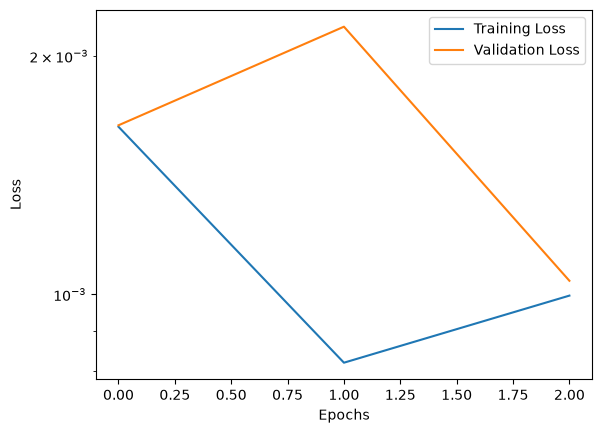

Minimum validation loss of 0.0010 occurred at epoch 3


In [23]:
plt.plot(epoch_loss_list, label='Training Loss')
plt.plot(val_loss_list, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.yscale('log')  # Use logarithmic scale for better visibility
plt.legend()
plt.show()

min_val_loss_epoch = np.argmin(val_loss_list)
print(f"Minimum validation loss of {val_loss_list[min_val_loss_epoch]:.4f} occurred at epoch {min_val_loss_epoch + 1}")

In [24]:
# --- Load site-split CSVs and memory-map the full-resolution global arrays ---
train_idx = pd.read_csv(DATA_DIR + '/train.csv', header=None)[0].values
val_idx   = pd.read_csv(DATA_DIR + '/val.csv',   header=None)[0].values
test_idx  = pd.read_csv(DATA_DIR + '/test.csv',  header=None)[0].values
print(f'train/val/test sites: {len(train_idx)} / {len(val_idx)} / {len(test_idx)}')

glob_X = np.load(GLOB_DIR + '/glob_X_fea.npy', mmap_mode='r')  # (54152, 40, 12, 136)

def load_glob_Y(age):
    return np.load(GLOB_DIR + f'/glob_Y{age:03d}.npy', mmap_mode='r')


train/val/test sites: 3035 / 338 / 50779


In [25]:
def global_arrays_rolling_monthly(site_idx, ages=AGES):
    """
    Rolling-monthly, engineered-feature analogue of meta_models.ipynb's `global_arrays_monthly`,
    for MonthlyDeltaRollout's (x_rolling, y_rolling) input shape. Loads only the December column
    from glob_Y{age}.npy -- all 12 months are numerically identical within a year (REPORT.md
    Sec 2.2), so this is exact, not an approximation, and avoids 12x the disk reads -- then
    broadcasts it across a dummy month axis purely so convert_to_rolling_monthly can consume it.
    """
    site_idx = np.asarray(site_idx)
    x_month = np.asarray(glob_X[site_idx])                      # (S, 40, 12, 136) physical
    x_month_n = normalize_x(x_month).astype(np.float32)

    y_dec_by_age = np.stack([
        np.asarray(load_glob_Y(a)[site_idx][:, :, 11, :]) for a in ages
    ], axis=1).astype(np.float32)                                # (S, A, 41, 7) physical December
    y_broadcast = np.repeat(y_dec_by_age[:, :, :, None, :], N_MONTH, axis=3)  # (S, A, 41, 12, 7)

    x_rolling_n, y_rolling = convert_to_rolling_monthly(x_month_n, y_broadcast)

    engineered, _ = engineering_features(x_rolling_n)
    x_rolling_n = np.concatenate([x_rolling_n, np.array(engineered).transpose(1, 2, 0)], axis=-1)
    return x_rolling_n, y_rolling  # y_rolling stays PHYSICAL


@torch.no_grad()
def rollout_global(model, x_rolling_n, y_rolling_phys, site_batch=512, device=device):
    """
    Autoregressive rollout given ONLY y0, mirroring rollout_meta_model -- then keeps only the 40
    true year-boundary steps (see the caveats above) so results compare against the tutorial/
    paper's annual benchmark table via metrics_table_global.
    Returns (pred, true), each (A, S, N_YEAR, N_OUT) PHYSICAL units.
    """
    model.eval()
    s_total, n_age = y_rolling_phys.shape[0], y_rolling_phys.shape[1]
    n_year = (y_rolling_phys.shape[2] - 1) // N_MONTH  # 40

    pred = np.empty((n_age, s_total, n_year, N_OUT), dtype=np.float32)
    true = y_rolling_phys[:, :, N_MONTH::N_MONTH, :].transpose(1, 0, 2, 3)  # years 1..40

    for start in range(0, s_total, site_batch):
        end = min(start + site_batch, s_total)
        x_batch = torch.as_tensor(x_rolling_n[start:end], dtype=torch.float32, device=device)
        y0_phys = y_rolling_phys[start:end, :, 0, :]
        y0_n = torch.as_tensor(normalize_x(y0_phys, y_mean, y_std), dtype=torch.float32, device=device)

        pred_n_full = model(x_batch, y0_n)                           # (bs, A, 480, N_OUT) normalized
        pred_n_annual = pred_n_full[:, :, N_MONTH - 1::N_MONTH, :]    # keep only the 40 year-boundary steps
        pred_phys = inv_x(pred_n_annual.cpu().numpy(), y_mean, y_std)
        pred[:, start:end, :, :] = pred_phys.transpose(1, 0, 2, 3)
    return pred, true


In [26]:
n_eval_sites = 500  # this model is 12x more expensive per site than the 40-step annual models
eval_idx = test_idx if n_eval_sites is None else np.random.RandomState(0).choice(test_idx, n_eval_sites, replace=False)

x_eval_n, y_eval_rolling = global_arrays_rolling_monthly(eval_idx, ages=AGES)
print(f'Autoregressive rollout on {len(eval_idx)} global test sites x {len(AGES)} ages (y0 given only)...')
pred_seq, true_seq = rollout_global(model, x_eval_n, y_eval_rolling)


global_metrics = metrics_table_global(true_seq, pred_seq)
print('MonthlyDeltaRollout -- 480-step monthly rollout, scored at the 40 annual checkpoints (physical units):')
global_metrics

Autoregressive rollout on 500 global test sites x 15 ages (y0 given only)...
MonthlyDeltaRollout -- 480-step monthly rollout, scored at the 40 annual checkpoints (physical units):


,RMSE,MAE,R2,delta,cumulative
height,105.936996,67.425003,-99.427002,6.131,208.908997
agb,129.306000,62.787998,-616.306030,8.868,292.726013
soil,103.275002,64.961998,-288.390015,4.726,179.044998
lai,21.209999,10.313000,-112.462997,2.175,56.700001
gpp,38.528999,18.445000,-805.585999,3.028,93.205002
npp,5.907000,3.665000,-79.560997,0.351,10.606000
rh,8.260000,4.368000,-180.419998,0.480,15.706000


In [27]:
global_metrics / baseline

,RMSE,MAE,R2,delta,cumulative
height,34.619933,43.953718,-108.782278,13.934091,47.200406
agb,95.569845,105.703701,-659.150835,54.073171,167.176478
soil,75.328229,89.726517,-303.249227,28.469879,88.548466
lai,36.071427,38.196295,-123.179625,5.253623,87.365178
gpp,103.018715,115.281248,-874.686209,9.612699,208.512308
npp,31.758065,46.392405,-86.762265,2.207547,47.774775
rh,45.384617,49.636364,-197.396059,2.637363,78.530002
